In [41]:
# Reading in the data and packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rats = pd.read_csv('rats_clean.csv')
rats['Council District'] = rats['Council District'].astype('category')
features = ['Problem Detail (formerly Descriptor)', 'Location Type', 'Incident Zip', 'City', 'Landmark', 'Community Board', 'Council District', 'Police Precinct', 'Borough', 'Latitude', 'Longitude']
y = (rats['confirmed'])
X = pd.get_dummies((rats[features]), drop_first = False)

In [42]:
# Setting up Training and Test Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=307, stratify = y)

In [43]:
FOREST = RandomForestClassifier(n_estimators=500, random_state=307, oob_score=True, n_jobs=-1)
FOREST.fit(X_train,y_train)

# Train Accuracy
y_pred = FOREST.predict(X_train)
train_accuracy = accuracy_score(y_pred, y_train)
print(f'Train Accuracy: {train_accuracy}')
print('')

# Test Accuracy
y_pred = FOREST.predict(X_test)
test_accuracy = accuracy_score(y_pred, y_test)
print(f'Test Accuracy: {test_accuracy}')
print('')

# OOB Score
print(f'OOB Score: {FOREST.oob_score_}')

Train Accuracy: 0.9516266394140691

Test Accuracy: 0.6499744506898314

OOB Score: 0.6523164707886221


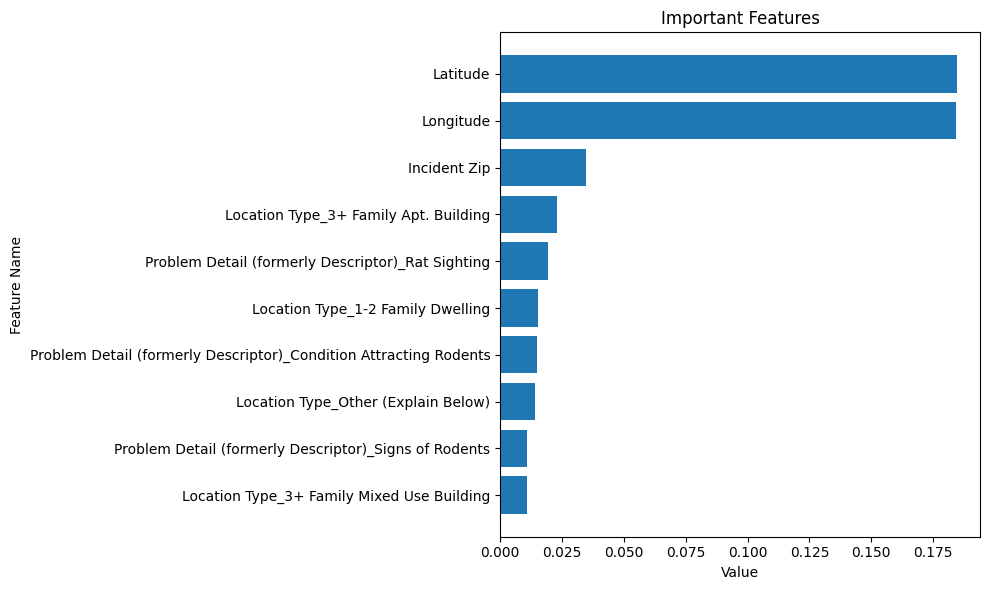

In [44]:
feat_imp = FOREST.feature_importances_

feature_names = X_train.columns
sorted_idx = np.argsort(feat_imp)[::-1]

sorted_feat_imp = feat_imp[sorted_idx][0:10]
sorted_features = feature_names[sorted_idx][0:10]

plt.figure(figsize=(10,6))
plt.barh(sorted_features, sorted_feat_imp)

plt.xlabel("Value")
plt.ylabel("Feature Name")
plt.title("Important Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()